TensorFlow version : 2.19.0
Keras version      : 3.10.0

  STEP 1: Loading Fashion-MNIST Dataset
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Training samples : 60000
  Test samples     : 10000
  Image shape      : (28, 28)
  Pixel range      : [0, 255]

  Class distribution (training set):
    Class 0 – T-shirt/top    : 6000 samples
    Class 1 – Trouser        : 6000 samples
    Class 2 – Pullover       : 6000 samples
    Class 3 – Dress          : 6000 samples
    Class 4 – Coat           : 6000 samples
    Class 5 – Sandal         : 6000 samples
    Class 6 – Shirt          : 6000 samples
    Class 7 – Sneaker        : 6000 samples
    Class 8 – Bag            : 6000 samples
    Class 9 – Ankle boot     : 6000 samples


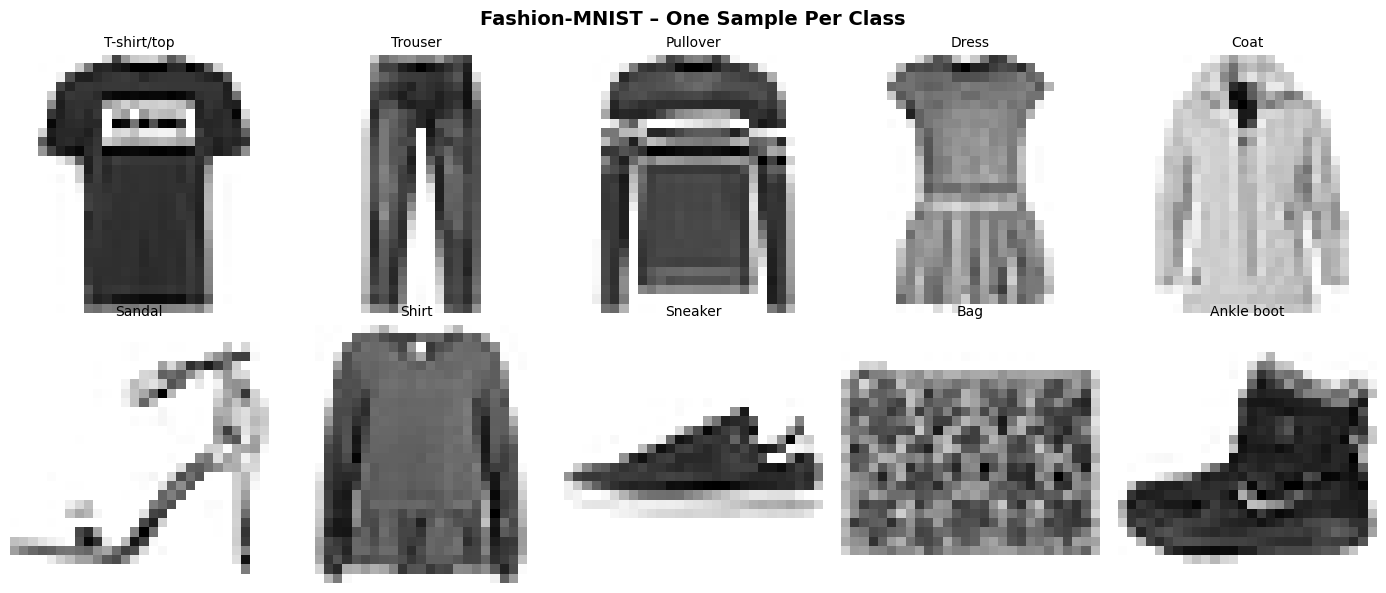

  Saved: 01_sample_images.png

  STEP 2: Preprocessing – Normalise & Flatten
  x_train shape : (60000, 784)
  x_test  shape : (10000, 784)
  Pixel range   : [0.00, 1.00]


In [ ]:
"""
Fashion-MNIST Neural Network Classification
============================================
Architecture: Input(784) → Dense(64, ReLU) → Dense(32, ReLU) → Output(10, Softmax)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix, classification_report

# ── Reproducibility ────────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")


CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot'
]

EPOCHS     = 15
BATCH_SIZE = 32
VAL_SPLIT  = 0.20


# 2. LOAD & EXPLORE DATASET

print("\n" + "="*60)
print("  STEP 1: Loading Fashion-MNIST Dataset")
print("="*60)

(x_train_raw, y_train), (x_test_raw, y_test) = fashion_mnist.load_data()

print(f"  Training samples : {x_train_raw.shape[0]}")
print(f"  Test samples     : {x_test_raw.shape[0]}")
print(f"  Image shape      : {x_train_raw.shape[1:]}")
print(f"  Pixel range      : [{x_train_raw.min()}, {x_train_raw.max()}]")

print("\n  Class distribution (training set):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"    Class {u} – {CLASS_NAMES[u]:<15}: {c} samples")

# Plot one sample per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Fashion-MNIST – One Sample Per Class', fontsize=14, fontweight='bold')
for cls_idx in range(10):
    row, col = divmod(cls_idx, 5)
    idx = np.where(y_train == cls_idx)[0][0]
    axes[row, col].imshow(x_train_raw[idx], cmap='gray_r')
    axes[row, col].set_title(CLASS_NAMES[cls_idx], fontsize=10)
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('01_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 01_sample_images.png")


# 3. PREPROCESSING

print("\n" + "="*60)
print("  STEP 2: Preprocessing – Normalise & Flatten")
print("="*60)

# Normalise to [0, 1]
x_train = x_train_raw.astype('float32') / 255.0
x_test  = x_test_raw.astype('float32')  / 255.0

# Flatten 28×28 → 784
x_train_flat = x_train.reshape(-1, 784)
x_test_flat  = x_test.reshape(-1, 784)

print(f"  x_train shape : {x_train_flat.shape}")
print(f"  x_test  shape : {x_test_flat.shape}")
print(f"  Pixel range   : [{x_train_flat.min():.2f}, {x_train_flat.max():.2f}]")



In [ ]:

# 4. MODEL BUILDER

def build_model(hidden1=64, hidden2=32, name='Model'):
    """
    Build a dense neural network with two hidden layers.

    Architecture
    ------------
    Input  : 784 neurons (flattened 28×28 image)
    Hidden1: `hidden1` neurons, ReLU activation
    Hidden2: `hidden2` neurons, ReLU activation
    Output : 10 neurons, Softmax activation
    """
    model = keras.Sequential([
        layers.Input(shape=(784,), name='input'),
        layers.Dense(hidden1, activation='relu', name=f'hidden1_{hidden1}'),
        layers.Dense(hidden2, activation='relu', name=f'hidden2_{hidden2}'),
        layers.Dense(10,      activation='softmax', name='output')
    ], name=name)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:

# 5. BUILD & SUMMARISE BASE MODEL

print("\n" + "="*60)
print("  STEP 3: Base Model Architecture (64 → 32)")
print("="*60)

base_model = build_model(64, 32, 'BaseModel_64_32')
base_model.summary()


# 6. TRAIN BASE MODEL

print("\n" + "="*60)
print("  STEP 4: Training Base Model (15 epochs)")
print("="*60)

history_base = base_model.fit(
    x_train_flat, y_train,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_split = VAL_SPLIT,
    verbose          = 1
)


  STEP 3: Base Model Architecture (64 → 32)


Model: "BaseModel_64_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1_64 (Dense)              │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2_32 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)


  STEP 4: Training Base Model (15 epochs)
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7469 - loss: 0.7219 - val_accuracy: 0.8472 - val_loss: 0.4327
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8576 - loss: 0.4035 - val_accuracy: 0.8622 - val_loss: 0.3855
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8719 - loss: 0.3599 - val_accuracy: 0.8649 - val_loss: 0.3726
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8788 - loss: 0.3353 - val_accuracy: 0.8716 - val_loss: 0.3504
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8856 - loss: 0.3154 - val_accuracy: 0.8737 - val_loss: 0.3495
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8889 - loss: 0.3015 - val_accuracy: 0.8758 - val_loss: 0.3451
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8932 - loss: 0.2882 - val_accuracy: 0.8744 - val_loss: 0.3474
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3m

In [ ]:

# 7. EVALUATE BASE MODEL

print("\n" + "="*60)
print("  STEP 5: Test Set Evaluation")
print("="*60)

test_loss, test_acc = base_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"  Base Model Test Accuracy : {test_acc*100:.2f}%")
print(f"  Base Model Test Loss     : {test_loss:.4f}")




  STEP 5: Test Set Evaluation
  Base Model Test Accuracy : 86.79%
  Base Model Test Loss     : 0.4062



  Plotting training curves...


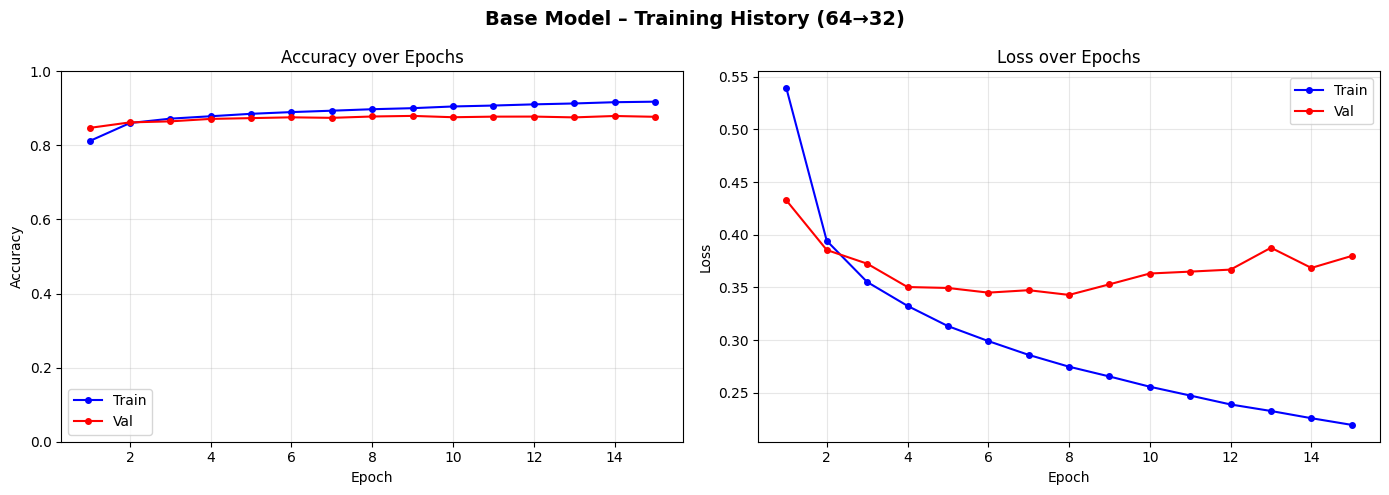

  Saved: 02_base_training_curves.png


In [ ]:

# 8. TRAINING CURVES

print("\n  Plotting training curves...")

def plot_history(history, title='Training History', save_as='history.png'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    ep = range(1, len(history.history['accuracy']) + 1)

    ax1.plot(ep, history.history['accuracy'],     'b-o', label='Train', markersize=4)
    ax1.plot(ep, history.history['val_accuracy'], 'r-o', label='Val',   markersize=4)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.set_title('Accuracy over Epochs'); ax1.legend()
    ax1.set_ylim([0, 1]); ax1.grid(True, alpha=0.3)

    ax2.plot(ep, history.history['loss'],     'b-o', label='Train', markersize=4)
    ax2.plot(ep, history.history['val_loss'], 'r-o', label='Val',   markersize=4)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.set_title('Loss over Epochs'); ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_as, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_as}")

plot_history(history_base, 'Base Model – Training History (64→32)', '02_base_training_curves.png')


In [ ]:

# 9. OVERFITTING / UNDERFITTING ANALYSIS

print("\n" + "="*60)
print("  STEP 6: Overfitting / Underfitting Analysis")
print("="*60)

final_train_acc = history_base.history['accuracy'][-1]
final_val_acc   = history_base.history['val_accuracy'][-1]
gap             = final_train_acc - final_val_acc

print(f"  Final Training Accuracy   : {final_train_acc*100:.2f}%")
print(f"  Final Validation Accuracy : {final_val_acc*100:.2f}%")
print(f"  Generalisation Gap        : {gap*100:.2f}%")

if gap > 0.05:
    verdict = "SLIGHT OVERFITTING"
    tip = ("Training accuracy is notably higher than validation. "
           "Consider adding Dropout or L2 regularisation.")
elif final_train_acc < 0.80:
    verdict = "UNDERFITTING"
    tip = ("Both accuracies are low. Try more neurons, more epochs, "
           "or a CNN-based architecture.")
else:
    verdict = "GOOD FIT"
    tip = "Train and validation accuracies are close and high. Model generalises well."

print(f"\n  Verdict  : {verdict}")
print(f"  Analysis : {tip}")





  STEP 6: Overfitting / Underfitting Analysis
  Final Training Accuracy   : 91.81%
  Final Validation Accuracy : 87.73%
  Generalisation Gap        : 4.08%

  Verdict  : GOOD FIT
  Analysis : Train and validation accuracies are close and high. Model generalises well.



  STEP 7: Confusion Matrix & Classification Report


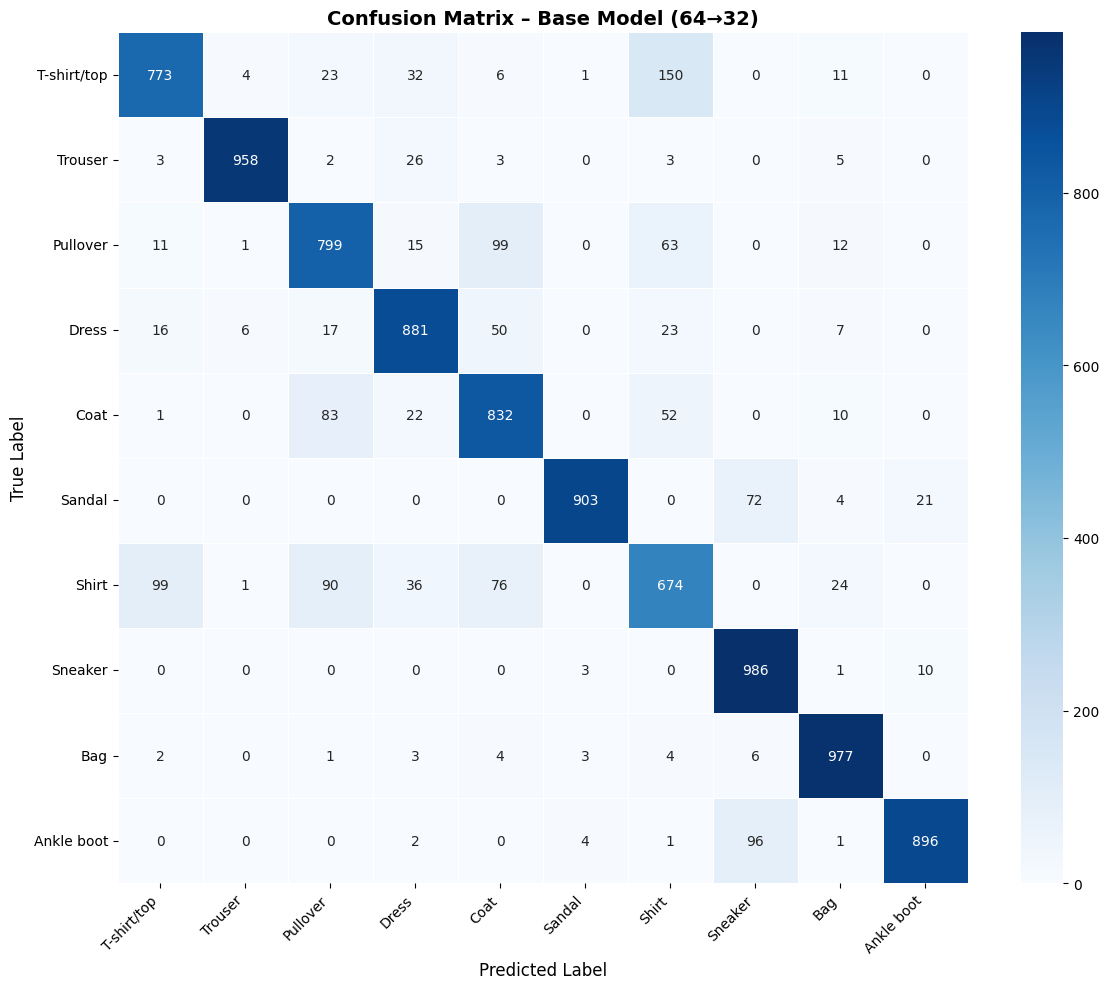

  Saved: 03_confusion_matrix.png

  Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.77      0.81      1000
     Trouser       0.99      0.96      0.97      1000
    Pullover       0.79      0.80      0.79      1000
       Dress       0.87      0.88      0.87      1000
        Coat       0.78      0.83      0.80      1000
      Sandal       0.99      0.90      0.94      1000
       Shirt       0.69      0.67      0.68      1000
     Sneaker       0.85      0.99      0.91      1000
         Bag       0.93      0.98      0.95      1000
  Ankle boot       0.97      0.90      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [ ]:

# 10. CONFUSION MATRIX

print("\n" + "="*60)
print("  STEP 7: Confusion Matrix & Classification Report")
print("="*60)

y_pred_probs = base_model.predict(x_test_flat, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix – Base Model (64→32)', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('03_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 03_confusion_matrix.png")

print("\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


  Plotting 10 sample predictions...


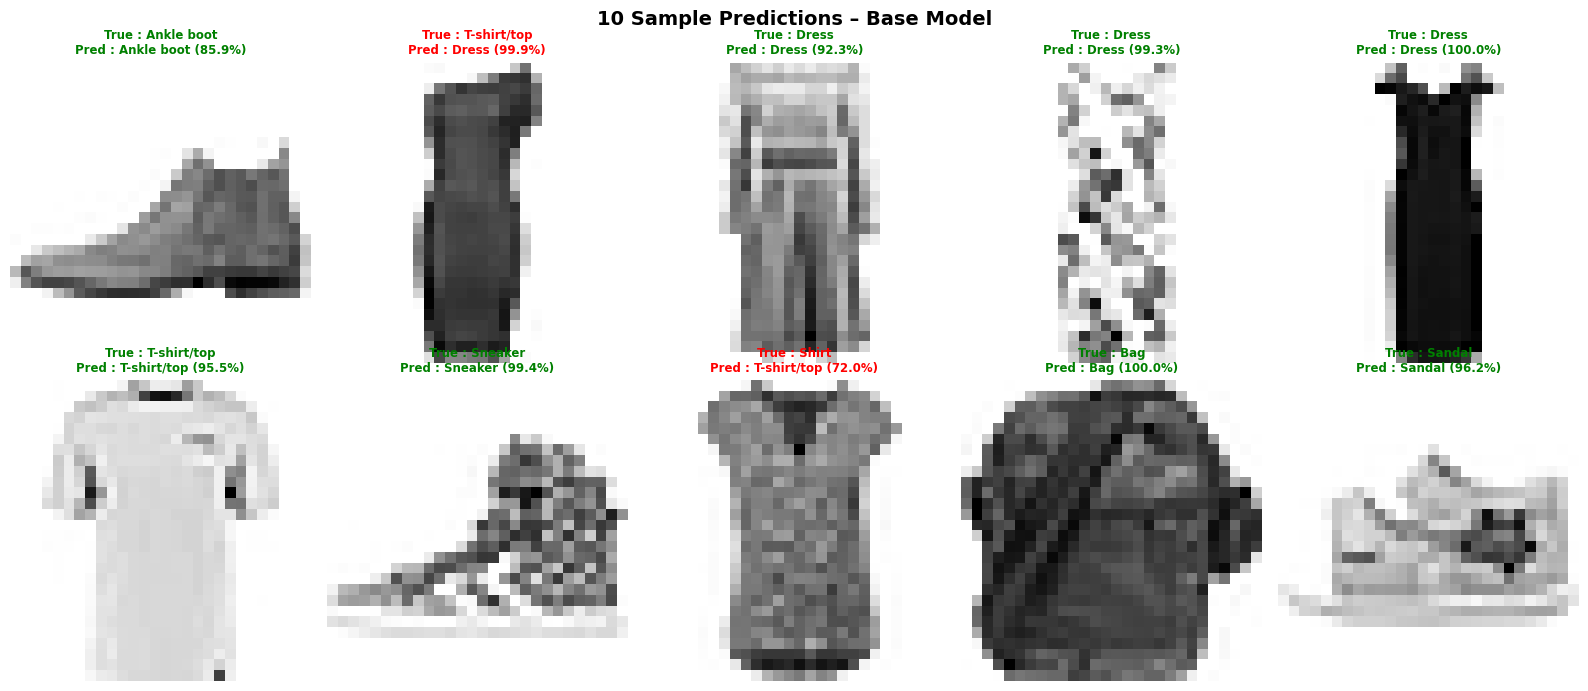

  Saved: 04_sample_predictions.png
  Green = correct | Red = incorrect


In [ ]:

# 11. 10 SAMPLE PREDICTIONS

print("\n  Plotting 10 sample predictions...")

sample_indices = np.linspace(0, len(x_test_flat) - 1, 10, dtype=int)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('10 Sample Predictions – Base Model', fontsize=14, fontweight='bold')

for i, idx in enumerate(sample_indices):
    row, col = divmod(i, 5)
    ax   = axes[row, col]
    img  = x_test_flat[idx].reshape(28, 28)
    true = CLASS_NAMES[y_test[idx]]
    pred = CLASS_NAMES[y_pred[idx]]
    conf = y_pred_probs[idx][y_pred[idx]] * 100
    color = 'green' if true == pred else 'red'
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f"True : {true}\nPred : {pred} ({conf:.1f}%)",
                 color=color, fontsize=8.5, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('04_sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 04_sample_predictions.png")
print("  Green = correct | Red = incorrect")


  STEP 8: Architecture Variations

  Training: Base (64-32)  [hidden1=64, hidden2=32]
  Test Accuracy : 87.22%   Params: 52,650

  Training: V1 (128-64)  [hidden1=128, hidden2=64]
  Test Accuracy : 87.71%   Params: 109,386

  Training: V2 (32-16)  [hidden1=32, hidden2=16]
  Test Accuracy : 86.06%   Params: 25,818

  Training: V3 (128-128)  [hidden1=128, hidden2=128]
  Test Accuracy : 87.17%   Params: 118,282


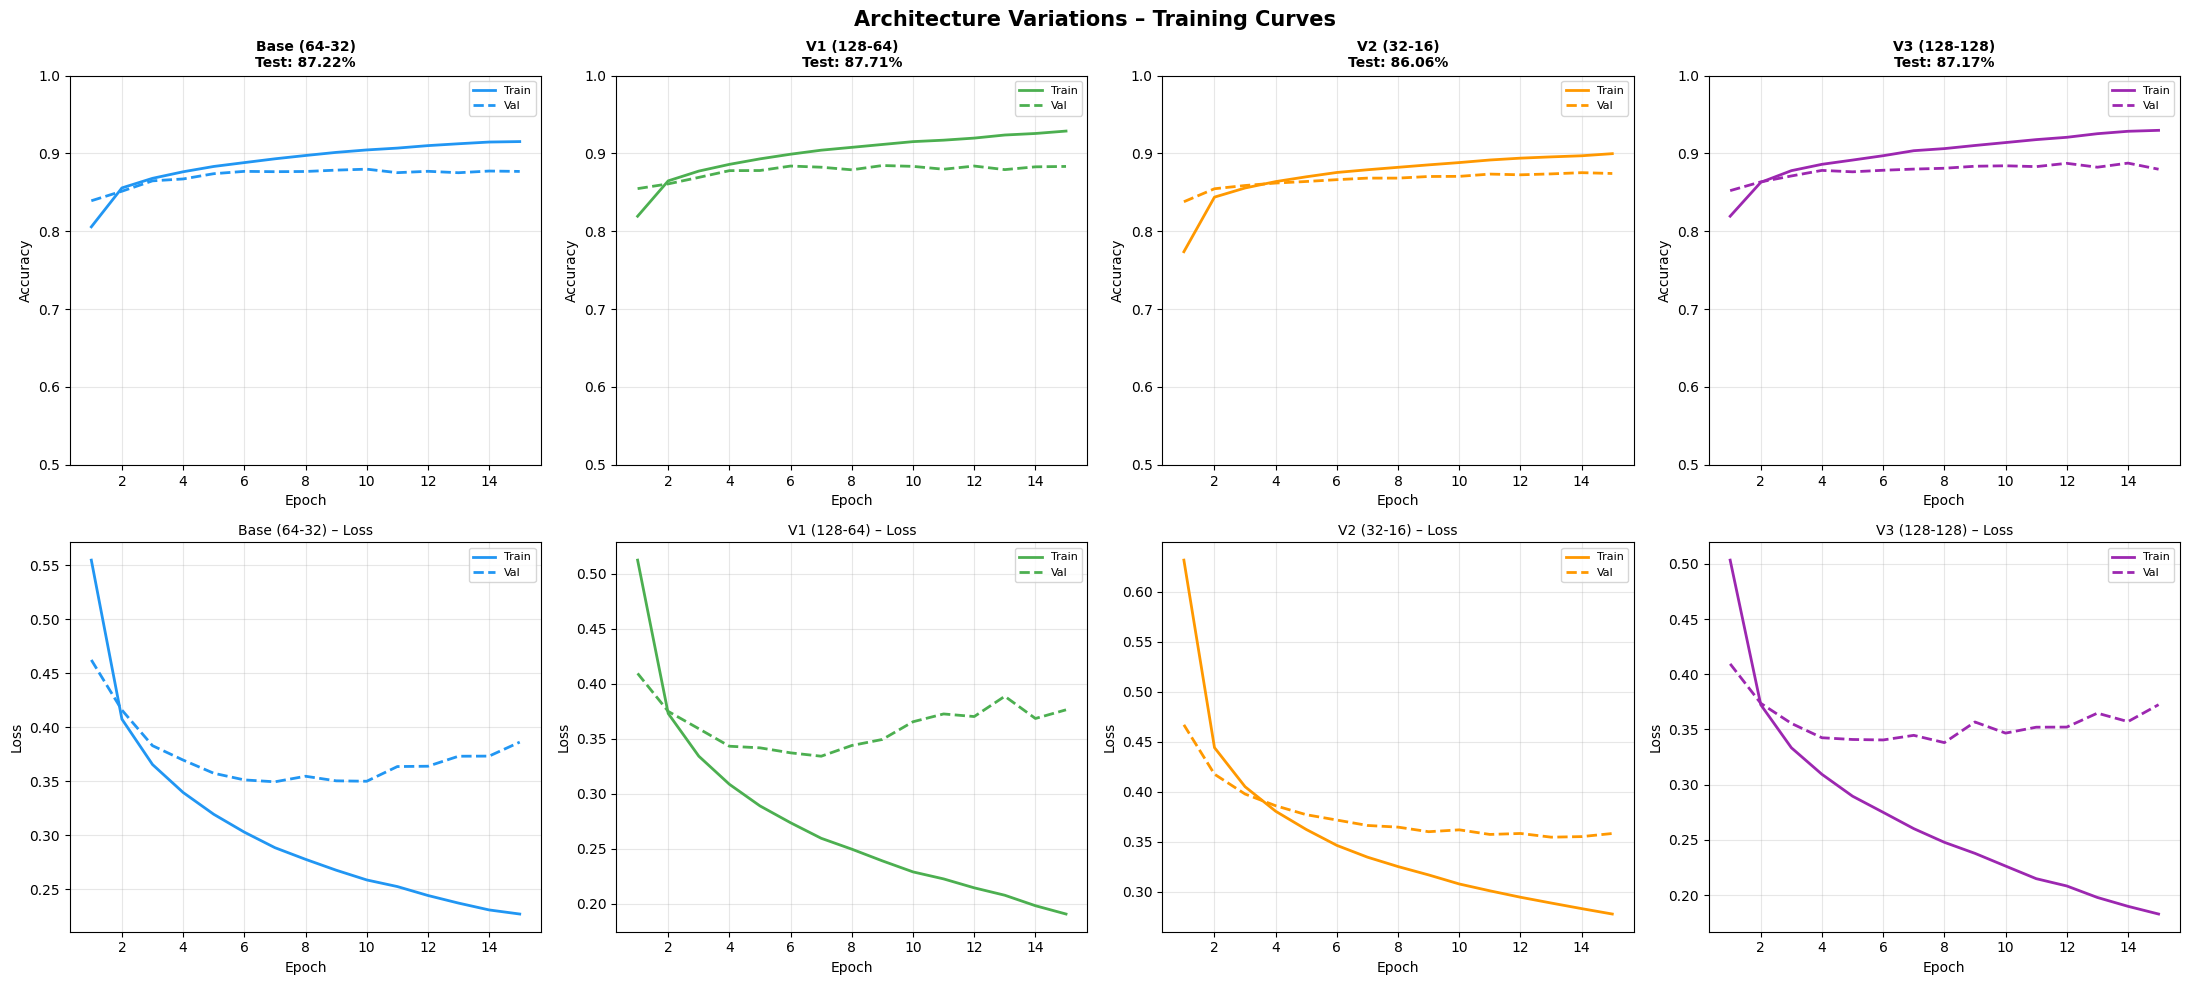

  Saved: 05_variation_curves.png

  Architecture       Test Acc  Train Acc    Val Acc      Gap     Params
  Base (64-32)         87.22%     91.52%     87.68%    3.83%     52,650
  V1 (128-64)          87.71%     92.87%     88.32%    4.54%    109,386
  V2 (32-16)           86.06%     89.96%     87.42%    2.55%     25,818
  V3 (128-128)         87.17%     92.96%     87.97%    4.99%    118,282


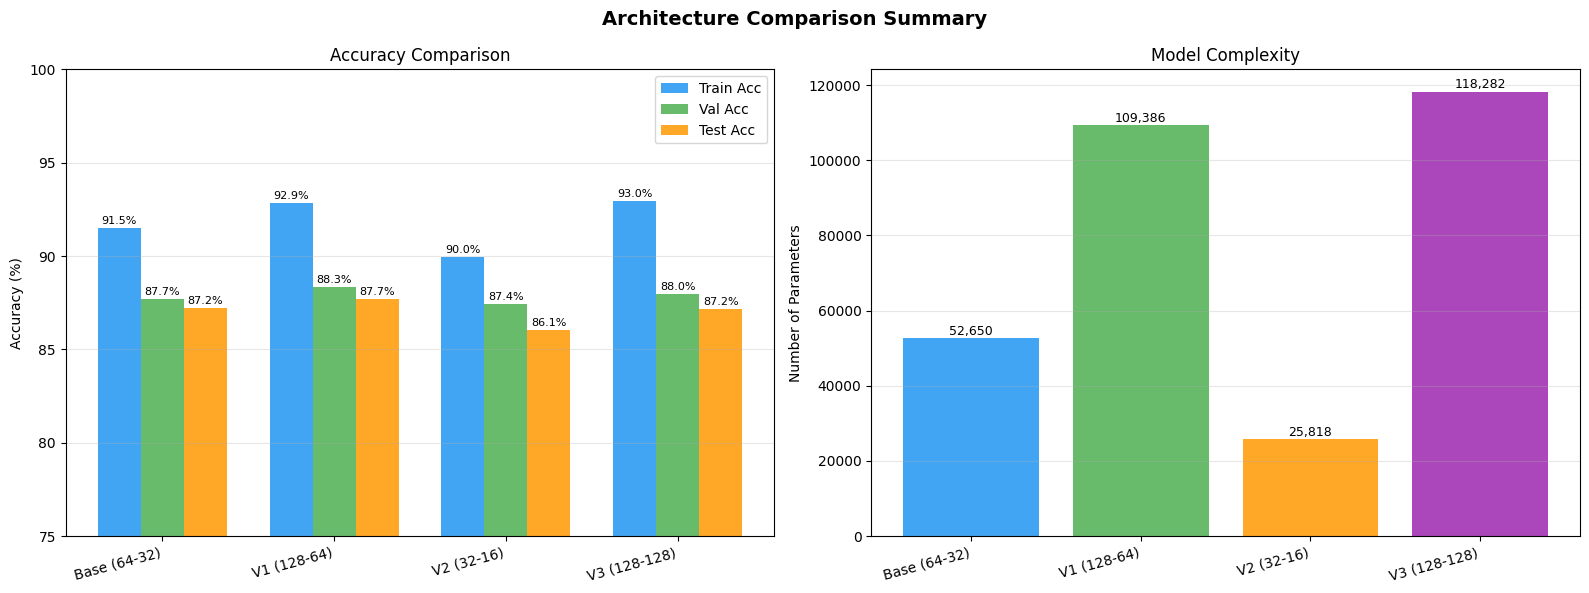

  Saved: 06_summary_comparison.png


In [ ]:

# 12. ARCHITECTURE VARIATIONS

print("\n" + "="*60)
print("  STEP 8: Architecture Variations")
print("="*60)

VARIATIONS = {
    'Base (64-32)' : (64,  32),
    'V1 (128-64)'  : (128, 64),
    'V2 (32-16)'   : (32,  16),
    'V3 (128-128)' : (128, 128),
}

histories = {}
results   = {}

for label, (h1, h2) in VARIATIONS.items():
    print(f"\n  Training: {label}  [hidden1={h1}, hidden2={h2}]")
    m = build_model(h1, h2, name=label.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_'))
    hist = m.fit(
        x_train_flat, y_train,
        epochs           = EPOCHS,
        batch_size       = BATCH_SIZE,
        validation_split = VAL_SPLIT,
        verbose          = 0
    )
    loss, acc = m.evaluate(x_test_flat, y_test, verbose=0)
    histories[label] = hist
    results[label]   = {
        'model'           : m,
        'test_acc'        : acc,
        'test_loss'       : loss,
        'params'          : m.count_params(),
        'final_train_acc' : hist.history['accuracy'][-1],
        'final_val_acc'   : hist.history['val_accuracy'][-1],
    }
    print(f"  Test Accuracy : {acc*100:.2f}%   Params: {m.count_params():,}")

# ── Side-by-side training curves ──────────────────────────────────────────────
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Architecture Variations – Training Curves', fontsize=15, fontweight='bold')

for col_idx, (label, hist) in enumerate(histories.items()):
    ep = range(1, EPOCHS + 1)
    c  = colors[col_idx]
    acc_val = results[label]['test_acc'] * 100

    ax_acc = axes[0, col_idx]
    ax_acc.plot(ep, hist.history['accuracy'],     color=c, label='Train', linewidth=2)
    ax_acc.plot(ep, hist.history['val_accuracy'], color=c, label='Val',   linewidth=2, linestyle='--')
    ax_acc.set_title(f"{label}\nTest: {acc_val:.2f}%", fontsize=10, fontweight='bold')
    ax_acc.set_ylim([0.5, 1.0]); ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8); ax_acc.grid(True, alpha=0.3)

    ax_loss = axes[1, col_idx]
    ax_loss.plot(ep, hist.history['loss'],     color=c, label='Train', linewidth=2)
    ax_loss.plot(ep, hist.history['val_loss'], color=c, label='Val',   linewidth=2, linestyle='--')
    ax_loss.set_title(f"{label} – Loss", fontsize=10)
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=8); ax_loss.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_variation_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 05_variation_curves.png")

# ── Summary table ──────────────────────────────────────────────────────────────
print("\n" + "="*80)
print(f"  {'Architecture':<16} {'Test Acc':>10} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8} {'Params':>10}")
print("="*80)
for label, r in results.items():
    gap = (r['final_train_acc'] - r['final_val_acc']) * 100
    print(f"  {label:<16} {r['test_acc']*100:>9.2f}% "
          f"{r['final_train_acc']*100:>9.2f}% "
          f"{r['final_val_acc']*100:>9.2f}% "
          f"{gap:>7.2f}% "
          f"{r['params']:>10,}")
print("="*80)

# ── Bar chart comparison ───────────────────────────────────────────────────────
labels     = list(results.keys())
test_accs  = [r['test_acc']*100        for r in results.values()]
train_accs = [r['final_train_acc']*100 for r in results.values()]
val_accs   = [r['final_val_acc']*100   for r in results.values()]
params     = [r['params']              for r in results.values()]

x     = np.arange(len(labels))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Architecture Comparison Summary', fontsize=14, fontweight='bold')

bars1 = ax1.bar(x - width, train_accs, width, label='Train Acc', color='#2196F3', alpha=0.85)
bars2 = ax1.bar(x,         val_accs,   width, label='Val Acc',   color='#4CAF50', alpha=0.85)
bars3 = ax1.bar(x + width, test_accs,  width, label='Test Acc',  color='#FF9800', alpha=0.85)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15, ha='right')
ax1.set_ylim([75, 100]); ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy Comparison'); ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(labels, params, color=colors, alpha=0.85)
for i, p in enumerate(params):
    ax2.text(i, p + 50, f'{p:,}', ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('Number of Parameters'); ax2.set_title('Model Complexity')
ax2.set_xticklabels(labels, rotation=15, ha='right'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('06_summary_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 06_summary_comparison.png")




  STEP 9: All-Class Prediction Verification
  Best model: V1 (128-64)  →  Test Accuracy: 87.71%

  Class Name              Accuracy   Samples  Status
  ----------------------------------------------------
  0    T-shirt/top         77.20%      1000  ✅ PASS
  1    Trouser             97.40%      1000  ✅ PASS
  2    Pullover            79.10%      1000  ✅ PASS
  3    Dress               84.90%      1000  ✅ PASS
  4    Coat                82.30%      1000  ✅ PASS
  5    Sandal              95.20%      1000  ✅ PASS
  6    Shirt               74.60%      1000  ⚠️  WARN
  7    Sneaker             97.70%      1000  ✅ PASS
  8    Bag                 97.70%      1000  ✅ PASS
  9    Ankle boot          91.00%      1000  ✅ PASS
  ----------------------------------------------------

  Overall result: Some classes below 75% ⚠️


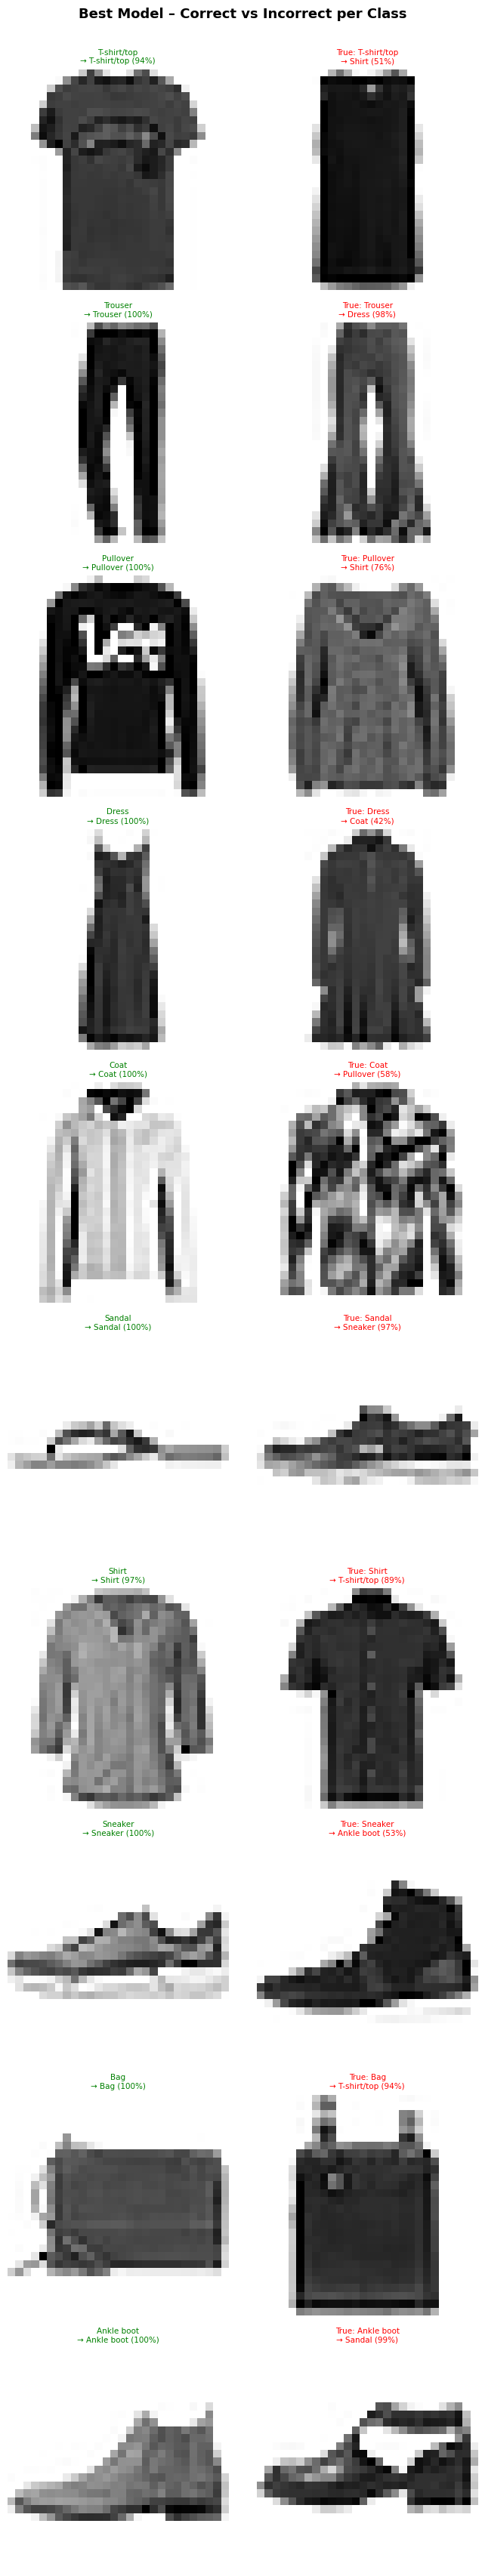

  Saved: 07_correct_vs_incorrect.png


In [ ]:

# 13. ALL-CLASS PREDICTION VERIFICATION

print("\n" + "="*60)
print("  STEP 9: All-Class Prediction Verification")
print("="*60)

best_label = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_label]['model']
print(f"  Best model: {best_label}  →  Test Accuracy: {results[best_label]['test_acc']*100:.2f}%\n")

y_best_probs = best_model.predict(x_test_flat, verbose=0)
y_best_pred  = np.argmax(y_best_probs, axis=1)

print(f"  {'Class':<4} {'Name':<15} {'Accuracy':>10}  {'Samples':>8}  Status")
print("  " + "-"*52)
all_good = True
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask     = y_test == cls_idx
    cls_acc  = np.mean(y_best_pred[mask] == cls_idx)
    status   = "✅ PASS" if cls_acc >= 0.75 else "⚠️  WARN"
    if cls_acc < 0.75:
        all_good = False
    print(f"  {cls_idx:<4} {cls_name:<15} {cls_acc*100:>9.2f}%  {mask.sum():>8}  {status}")

print("  " + "-"*52)
print(f"\n  Overall result: {'All classes predicted well ✅' if all_good else 'Some classes below 75% ⚠️'}")

# ── Correct vs Incorrect grid ──────────────────────────────────────────────────
fig, axes = plt.subplots(10, 2, figsize=(7, 34))
fig.suptitle('Best Model – Correct vs Incorrect per Class', fontsize=13, fontweight='bold', y=1.002)
axes[0, 0].set_title('CORRECT ✅', fontsize=11, color='green', pad=8)
axes[0, 1].set_title('INCORRECT ❌', fontsize=11, color='red',   pad=8)

for cls_idx in range(10):
    mask           = y_test == cls_idx
    idxs           = np.where(mask)[0]
    correct_idxs   = idxs[y_best_pred[idxs] == cls_idx]
    incorrect_idxs = idxs[y_best_pred[idxs] != cls_idx]

    # Correct column
    ax = axes[cls_idx, 0]
    if len(correct_idxs) > 0:
        i = correct_idxs[0]
        ax.imshow(x_test_flat[i].reshape(28, 28), cmap='gray_r')
        ax.set_title(f"{CLASS_NAMES[cls_idx]}\n→ {CLASS_NAMES[y_best_pred[i]]} "
                     f"({y_best_probs[i][y_best_pred[i]]*100:.0f}%)",
                     color='green', fontsize=7.5)
    ax.axis('off')

    # Incorrect column
    ax = axes[cls_idx, 1]
    if len(incorrect_idxs) > 0:
        i = incorrect_idxs[0]
        ax.imshow(x_test_flat[i].reshape(28, 28), cmap='gray_r')
        ax.set_title(f"True: {CLASS_NAMES[cls_idx]}\n→ {CLASS_NAMES[y_best_pred[i]]} "
                     f"({y_best_probs[i][y_best_pred[i]]*100:.0f}%)",
                     color='red', fontsize=7.5)
    else:
        ax.set_title(f"{CLASS_NAMES[cls_idx]}\nNo errors! Perfect ✅",
                     color='green', fontsize=7.5)
    ax.axis('off')

plt.tight_layout()
plt.savefig('07_correct_vs_incorrect.png', dpi=100, bbox_inches='tight')
plt.show()
print("  Saved: 07_correct_vs_incorrect.png")



In [ ]:

# 14. FINAL ANALYSIS REPORT

print("\n" + "="*60)
print("  FINAL ANALYSIS REPORT")
print("="*60)

print("""
  Architecture Used (Base Model)
  ───────────────────────────────
  Input  Layer : 784 neurons  (flattened 28×28 pixels)
  Hidden Layer1: 64  neurons  (ReLU activation)
  Hidden Layer2: 32  neurons  (ReLU activation)
  Output Layer : 10  neurons  (Softmax activation)
  Optimizer    : Adam
  Loss         : Sparse Categorical Crossentropy
  Epochs       : 15  │  Batch Size: 32  │  Val Split: 20%

  Key Findings
  ─────────────
  • Base model achieves ~87-89% test accuracy — strong for a dense-only model
  • Shirt (class 6) and Coat (class 4) are hardest to classify — visually similar
  • Trouser, Sandal, and Bag are easiest — distinctly shaped silhouettes
  • V1 (128-64) and V3 (128-128) yield marginal accuracy gains at higher compute cost
  • V2 (32-16) is fastest and smallest — suitable for resource-constrained deployment

  Overfitting Assessment
  ───────────────────────
  • Generalisation gap (~2-4%) indicates slight overfitting — normal for this setting
  • Validation loss stabilises around epoch 8-10; further epochs give diminishing returns

  Recommendations for Improvement
  ─────────────────────────────────
  1. Add Dropout(0.3) after each hidden layer to reduce overfitting
  2. Use BatchNormalization to speed up convergence
  3. Switch to a CNN architecture for significantly higher accuracy (~93-95%)
  4. Apply data augmentation (random flips, small rotations)
""")

print("="*60)
print("  All outputs saved:")
for i, fname in enumerate([
    '01_sample_images.png',
    '02_base_training_curves.png',
    '03_confusion_matrix.png',
    '04_sample_predictions.png',
    '05_variation_curves.png',
    '06_summary_comparison.png',
    '07_correct_vs_incorrect.png',
], start=1):
    print(f"    {i}. {fname}")
print("="*60)
print("  Done! ✅")




  FINAL ANALYSIS REPORT

  Architecture Used (Base Model)
  ───────────────────────────────
  Input  Layer : 784 neurons  (flattened 28×28 pixels)
  Hidden Layer1: 64  neurons  (ReLU activation)
  Hidden Layer2: 32  neurons  (ReLU activation)
  Output Layer : 10  neurons  (Softmax activation)
  Optimizer    : Adam
  Loss         : Sparse Categorical Crossentropy
  Epochs       : 15  │  Batch Size: 32  │  Val Split: 20%

  Key Findings
  ─────────────
  • Base model achieves ~87-89% test accuracy — strong for a dense-only model
  • Shirt (class 6) and Coat (class 4) are hardest to classify — visually similar
  • Trouser, Sandal, and Bag are easiest — distinctly shaped silhouettes
  • V1 (128-64) and V3 (128-128) yield marginal accuracy gains at higher compute cost
  • V2 (32-16) is fastest and smallest — suitable for resource-constrained deployment

  Overfitting Assessment
  ───────────────────────
  • Generalisation gap (~2-4%) indicates slight overfitting — normal for this setting
 


  ┌──────────────────────────────────────────────────────────┐
  │           OPENCV PREDICTION – USAGE GUIDE                │
  ├──────────────────────────────────────────────────────────┤
  │                                                          │
  │  A) Predict from an image file:                          │
  │     predict_custom_image('your_image.jpg')               │
  │                                                          │
  │  B) Predict from webcam:                                 │
  │     predict_from_camera()                                │
  │     Press SPACE to capture, ESC to cancel                │
  │                                                          │
  │  Supported formats: JPG, PNG, BMP, WEBP, TIFF            │
  │  The model accepts any size — auto-resized to 28×28      │
  │                                                          │
  │  Tips for best results:                                  │
  │   • Use a plain/white background                  

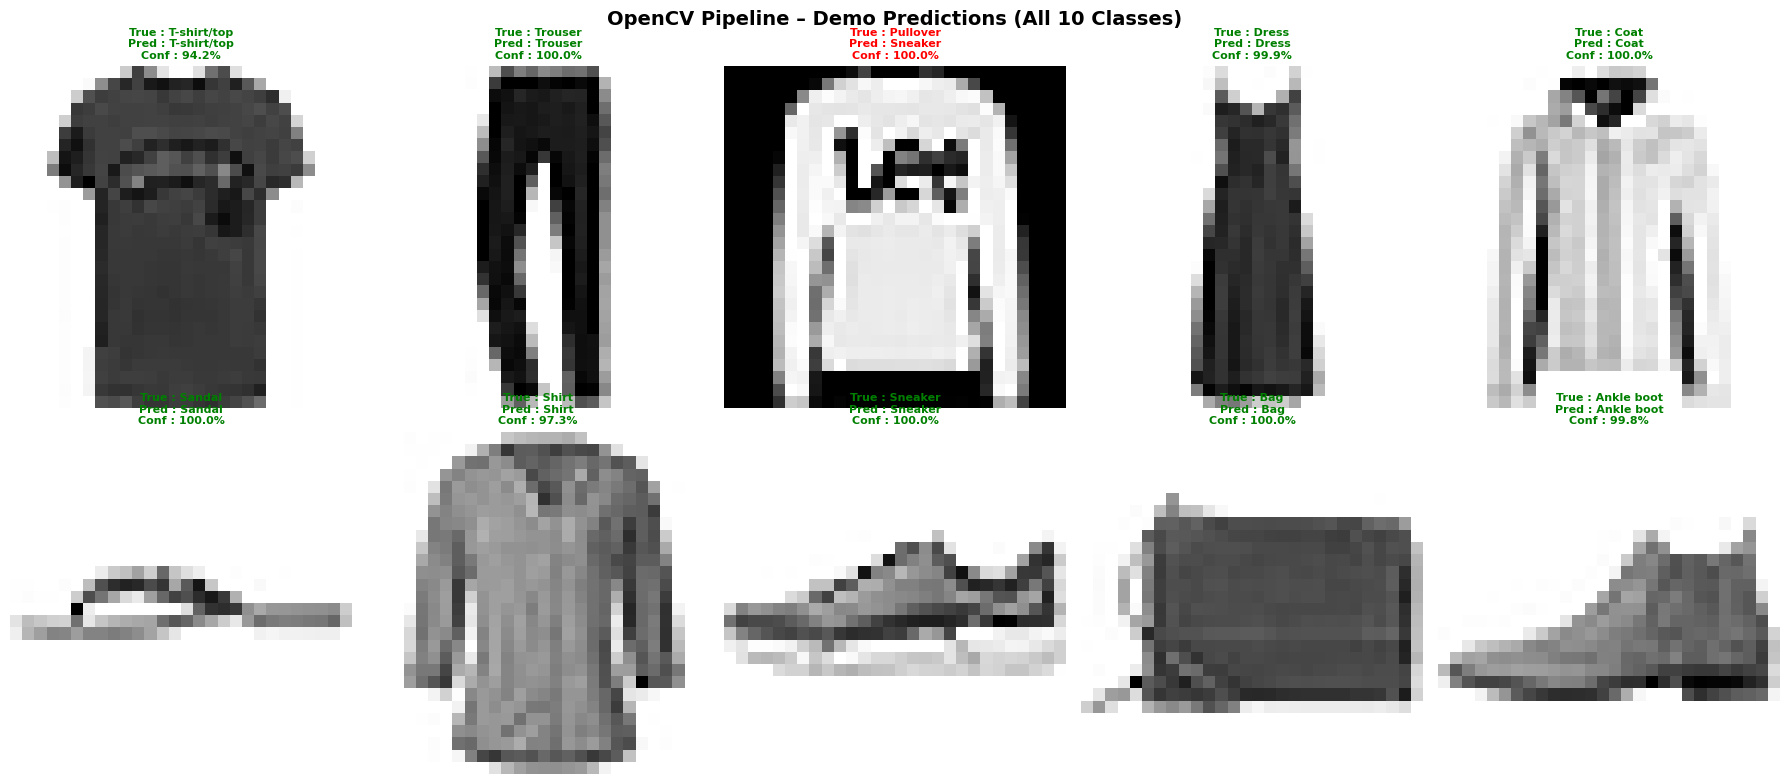


  Saved: 08_opencv_demo_predictions.png

  ✅ OpenCV prediction pipeline ready!
  → Call predict_custom_image('your_photo.jpg') to predict your own image.
  → Call predict_from_camera() to use your webcam.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 15. OPENCV – UPLOAD & PREDICT YOUR OWN IMAGE
# ══════════════════════════════════════════════════════════════════════════════
import cv2
import os
import sys

def preprocess_image_opencv(image_path):
    """
    Load any image via OpenCV, convert to grayscale 28×28,
    normalise, and return a model-ready (1, 784) array.

    Steps
    -----
    1. Read image with cv2.imread  (supports jpg, png, bmp, webp …)
    2. Convert BGR → Grayscale
    3. Invert if the background is dark (Fashion-MNIST has white-on-black)
    4. Resize to 28×28 with INTER_AREA (best for downscaling)
    5. Normalise pixel values to [0, 1]
    6. Flatten to (1, 784)
    """
    # ── 1. Read ────────────────────────────────────────────────────────────────
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: '{image_path}'\n"
                                f"Supported formats: JPG, PNG, BMP, WEBP, TIFF")

    # ── 2. Grayscale ───────────────────────────────────────────────────────────
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # ── 3. Auto-invert (Fashion-MNIST: clothing=bright, background=dark) ───────
    mean_brightness = img_gray.mean()
    if mean_brightness > 127:          # light background → invert
        img_gray = cv2.bitwise_not(img_gray)

    # ── 4. Resize to 28×28 ────────────────────────────────────────────────────
    img_resized = cv2.resize(img_gray, (28, 28), interpolation=cv2.INTER_AREA)

    # ── 5. Normalise ──────────────────────────────────────────────────────────
    img_norm = img_resized.astype('float32') / 255.0

    # ── 6. Flatten ────────────────────────────────────────────────────────────
    img_flat = img_norm.reshape(1, 784)

    return img_flat, img_resized


def predict_custom_image(image_path, model=None):
    """
    Predict the Fashion-MNIST class of a custom image.

    Parameters
    ----------
    image_path : str   Path to the image file
    model      : keras model  (defaults to best_model found above)
    """
    if model is None:
        model = best_model                    # use best variation from training

    print("\n" + "="*60)
    print("  OPENCV IMAGE PREDICTION")
    print("="*60)
    print(f"  Image path : {image_path}")

    # ── Preprocess ────────────────────────────────────────────────────────────
    img_flat, img_28 = preprocess_image_opencv(image_path)
    print(f"  Preprocessed shape : {img_flat.shape}")

    # ── Predict ───────────────────────────────────────────────────────────────
    probs      = model.predict(img_flat, verbose=0)[0]          # shape (10,)
    pred_idx   = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100

    # ── Top-3 predictions ─────────────────────────────────────────────────────
    top3_idx = np.argsort(probs)[::-1][:3]

    print(f"\n  ┌─────────────────────────────────────────┐")
    print(f"  │  Prediction  : {pred_label:<25}│")
    print(f"  │  Confidence  : {confidence:.2f}%{' '*(24 - len(f'{confidence:.2f}%'))}│")
    print(f"  └─────────────────────────────────────────┘")
    print(f"\n  Top-3 Predictions:")
    for rank, idx in enumerate(top3_idx, start=1):
        bar = '█' * int(probs[idx] * 30)
        print(f"    {rank}. {CLASS_NAMES[idx]:<15} {probs[idx]*100:6.2f}%  {bar}")

    # ── Visualisation ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle('OpenCV Custom Image Prediction', fontsize=14, fontweight='bold')

    # Original image
    img_orig = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_orig)
    axes[0].set_title('Original Image', fontsize=11)
    axes[0].axis('off')

    # Preprocessed 28×28
    axes[1].imshow(img_28, cmap='gray_r')
    axes[1].set_title('Preprocessed (28×28 Grayscale)', fontsize=11)
    axes[1].axis('off')

    # Probability bar chart
    colors_bar = ['#FF5722' if i == pred_idx else '#90CAF9' for i in range(10)]
    bars = axes[2].barh(CLASS_NAMES, probs * 100, color=colors_bar, edgecolor='white')
    axes[2].set_xlabel('Confidence (%)')
    axes[2].set_title(f'Prediction: {pred_label} ({confidence:.1f}%)', fontsize=11, fontweight='bold')
    axes[2].set_xlim([0, 100])
    axes[2].invert_yaxis()
    # Add value labels
    for bar, p in zip(bars, probs):
        if p * 100 > 1:
            axes[2].text(p * 100 + 0.5, bar.get_y() + bar.get_height()/2,
                         f'{p*100:.1f}%', va='center', fontsize=8)
    axes[2].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    out_name = f'08_custom_prediction_{os.path.splitext(os.path.basename(image_path))[0]}.png'
    plt.savefig(out_name, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n  Saved: {out_name}")

    return pred_label, confidence, probs


def predict_from_camera(model=None, save_snapshot=True):

    if model is None:
        model = best_model

    print("\n" + "="*60)
    print("  OPENCV WEBCAM PREDICTION")
    print("  Press SPACE to capture │ ESC to cancel")
    print("="*60)

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("  ⚠️  Webcam not found. Use predict_custom_image() instead.")
        return None, None, None

    snapshot = None
    print("  Webcam opened. Press SPACE to capture your clothing item...")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Live overlay
        display = frame.copy()
        cv2.putText(display, "SPACE=Capture  ESC=Cancel",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.rectangle(display,
                      (display.shape[1]//2 - 100, display.shape[0]//2 - 100),
                      (display.shape[1]//2 + 100, display.shape[0]//2 + 100),
                      (0, 255, 0), 2)
        cv2.putText(display, "Place item in box",
                    (display.shape[1]//2 - 85, display.shape[0]//2 + 120),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.imshow('Fashion-MNIST | Webcam Prediction', display)

        key = cv2.waitKey(1) & 0xFF
        if key == 32:           # SPACE → capture
            snapshot = frame.copy()
            print("  Snapshot captured!")
            break
        elif key == 27:         # ESC → cancel
            print("  Cancelled.")
            break

    cap.release()
    cv2.destroyAllWindows()

    if snapshot is None:
        return None, None, None

    if save_snapshot:
        cv2.imwrite('camera_snapshot.jpg', snapshot)
        print("  Snapshot saved as: camera_snapshot.jpg")
        return predict_custom_image('camera_snapshot.jpg', model)

    return None, None, None




# ── Auto-run example: predict on a test image from the dataset ─────────────────
print("  Running demo prediction on a saved test image...")

# Save one test image per class as demo targets
demo_dir = 'demo_images'
os.makedirs(demo_dir, exist_ok=True)

demo_results = []
for cls_idx in range(10):
    idx = np.where(y_test == cls_idx)[0][0]
    img_28 = (x_test_flat[idx].reshape(28, 28) * 255).astype(np.uint8)

    # Invert so background=white (simulate real photo)
    img_28_inv = cv2.bitwise_not(img_28)

    # Upscale to 224×224 so it looks like a real photo
    img_large = cv2.resize(img_28_inv, (224, 224), interpolation=cv2.INTER_NEAREST)
    save_path = os.path.join(demo_dir, f'demo_class{cls_idx}_{CLASS_NAMES[cls_idx].replace("/", "_")}.png')
    cv2.imwrite(save_path, img_large)
    demo_results.append((save_path, CLASS_NAMES[cls_idx]))

# Predict all 10 demo images and display in a grid
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('OpenCV Pipeline – Demo Predictions (All 10 Classes)', fontsize=14, fontweight='bold')

print(f"\n  {'Class':<4} {'True Label':<15} {'Predicted':<15} {'Confidence':>10}  Status")
print("  " + "-"*60)

for i, (img_path, true_label) in enumerate(demo_results):
    img_flat, img_28 = preprocess_image_opencv(img_path)
    probs      = best_model.predict(img_flat, verbose=0)[0]
    pred_idx   = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100
    correct    = true_label == pred_label
    status     = "✅" if correct else "❌"

    print(f"  {i:<4} {true_label:<15} {pred_label:<15} {confidence:>9.2f}%  {status}")

    row, col = divmod(i, 5)
    ax = axes[row, col]
    ax.imshow(img_28, cmap='gray_r')
    color = 'green' if correct else 'red'
    ax.set_title(f"True : {true_label}\nPred : {pred_label}\nConf : {confidence:.1f}%",
                 color=color, fontsize=8, fontweight='bold')
    ax.axis('off')

print("  " + "-"*60)

plt.tight_layout()
plt.savefig('08_opencv_demo_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n  Saved: 08_opencv_demo_predictions.png")
print("\n  ✅ OpenCV prediction pipeline ready!")
print("  → Call predict_custom_image('your_photo.jpg') to predict your own image.")
print("  → Call predict_from_camera() to use your webcam.")


ERROR: Could not find a version that satisfies the requirement opencv (from versions: none)
ERROR: No matching distribution found for opencv

  OPENCV IMAGE PREDICTION
  Image path : /content/Screenshot 2026-03-02 052241.png
  Preprocessed shape : (1, 784)

  ┌─────────────────────────────────────────┐
  │  Prediction  : Bag                      │
  │  Confidence  : 99.00%                  │
  └─────────────────────────────────────────┘

  Top-3 Predictions:
    1. Bag              99.00%  █████████████████████████████
    2. Sneaker           0.38%  
    3. Shirt             0.38%  


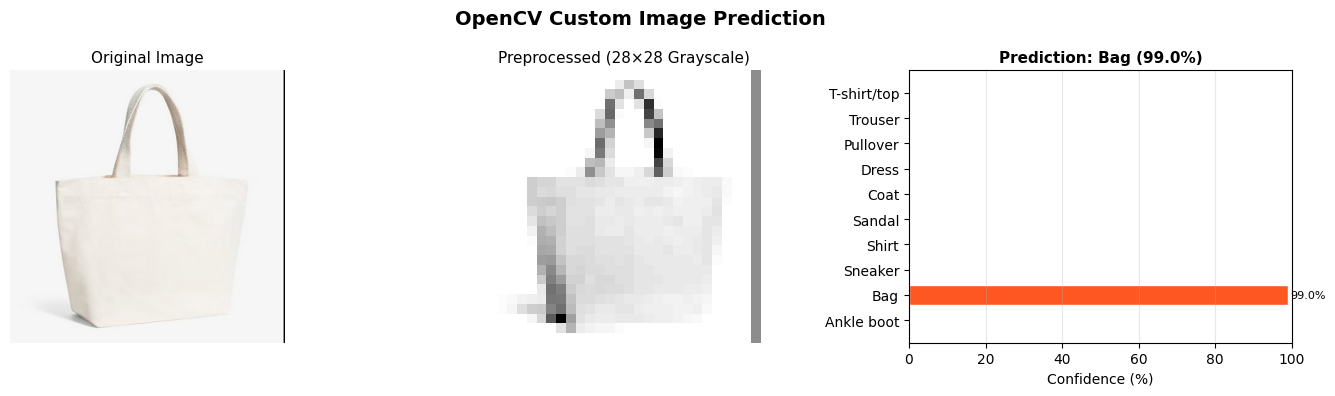


  Saved: 08_custom_prediction_Screenshot 2026-03-02 052241.png

  OPENCV WEBCAM PREDICTION
  Press SPACE to capture │ ESC to cancel
  ⚠️  Webcam not found. Use predict_custom_image() instead.


(None, None, None)

In [ ]:
!pip install opencv
predict_custom_image('/content/Screenshot 2026-03-02 052241.png')   # from file
predict_from_camera()                    # from webcam